# Chatbot Municipal con NLP

En este notebook se desarrollará el backend de un chatbot orientado a la gestión de trámites municipales, tomando como caso de estudio el Municipio de Río Grande.

## Objetivos

- Comprender cómo una máquina procesa lenguaje natural
- Aplicar técnicas de NLP vistas en la materia:
  - Tokenización
  - Normalización
  - Vectorización (TF-IDF)
- Implementar un modelo de clasificación de texto
- Identificar la intención del usuario (clasificación supervisada)
- Generar respuestas automáticas en función de dicha intención

---

## Enfoque desde NLP

Este proyecto se basa en el uso de técnicas de Procesamiento de Lenguaje Natural (NLP), donde el texto ingresado por el usuario es transformado y procesado en distintas etapas:

1. Entrada en lenguaje natural  
   El usuario escribe una consulta (por ejemplo: "quiero pagar impuestos")

2. Preprocesamiento del texto  
   Se aplican técnicas como tokenización y normalización para limpiar y estandarizar el texto

3. Representación vectorial  
   El texto se convierte en una representación numérica mediante técnicas como TF-IDF

4. Clasificación de la intención  
   Se utiliza un modelo de aprendizaje supervisado para predecir la intención del usuario (por ejemplo: "impuestos", "licencia", etc.)

5. Generación de respuesta  
   A partir de la intención detectada, el sistema devuelve una respuesta predefinida

---

## Dataset utilizado

El sistema se entrena utilizando un dataset de tipo sintético, estructurado en formato JSON.

Este dataset contiene:

- patterns: ejemplos de cómo los usuarios podrían expresarse  
- tag: la intención asociada a esos textos  
- responses: posibles respuestas del sistema  

Este enfoque permite simular un escenario real sin necesidad de utilizar datos sensibles o privados.

---

## Caso de estudio

El chatbot se orienta a consultas frecuentes de un municipio, tales como:

- Estacionamiento medido  
- Licencias de conducir  
- Impuestos municipales  
- Carnet de manipulación de alimentos  

---

## Relación con los contenidos de la materia

Este proyecto integra de manera práctica los siguientes temas trabajados:

- Representación del lenguaje (BoW / TF-IDF)
- Modelos de clasificación de texto
- Preprocesamiento de texto
- Aprendizaje supervisado aplicado a NLP

---

## Conclusión

El desarrollo de este chatbot permite comprender cómo los conceptos teóricos de NLP pueden aplicarse en un sistema real, evidenciando tanto sus capacidades como sus limitaciones en el procesamiento del lenguaje humano.

In [ ]:
import json

with open("intents.json", encoding="utf-8") as f:
    intents = json.load(f)

In [ ]:
#EXPLORAR LOS DATOS
print(len(intents["intents"]))

4


In [ ]:
for intent in intents["intents"]:
    print(intent["tag"])

estacionamiento_medido
licencia_conducir
impuestos
carnet_alimentos


In [ ]:
#PREPROCESAMIENTO
#Tokenización → separar palabras
#stemming → reducir palabras
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') #

from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("spanish")

def preprocess(text):
    tokens = nltk.word_tokenize(text.lower(), language='spanish')
    tokens = [stemmer.stem(w) for w in tokens]
    return " ".join(tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
corpus = [] #CREAR DATASET PARA EL MODELO
tags = []

for intent in intents["intents"]: #inicializás listas
    for pattern in intent["patterns"]:
        corpus.append(preprocess(pattern))
        tags.append(intent["tag"])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer #VECTORIZACIoN

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

| Paso                   | Concepto NLP                |
| ---------------------- | --------------------------- |
| preprocess             | normalización               |
| corpus/tags            | dataset supervisado         |
| TF-IDF                 | representación del lenguaje |



In [ ]:
from sklearn.ensemble import RandomForestClassifier #MODELO

model = RandomForestClassifier()
model.fit(X, tags)

RandomForestClassifier()

In [ ]:
#Funcion para: limpia el texto (NLP)
#lo convierte en números
#el modelo predice la intención
def predict(text):
    text = preprocess(text)
    vector = vectorizer.transform([text])
    return model.predict(vector)[0]

In [ ]:
#Fucion para buscar respuesta segun la intencion, random para no repetir
import random

def get_response(tag):
    for intent in intents["intents"]:
        if intent["tag"] == tag:
            return random.choice(intent["responses"])

In [ ]:
import random #AUGMENTACIÓN para contemplar distintas formas de hablar

def augment_text(text):
    variantes = [
        text,
        text + " por favor",
        "hola, " + text,
        text + " urgente",
        "me podes decir " + text
    ]
    return random.choice(variantes)

In [ ]:
def chatbot(text): #CHATBOT FINAL recibe, predice y devuelve
    tag = predict(text)
    return get_response(tag)

| Parte        | Concepto         |
| ------------ | ---------------- |
| RandomForest | modelo           |
| predict      | inferencia       |
| chatbot      | sistema completo |


In [ ]:
chatbot("quiero sacar licencia")

'Podés iniciar el trámite de licencia solicitando turno y cumpliendo los requisitos correspondientes'

In [ ]:
chatbot("cuanto debo de impuestos")

'Podés consultar y pagar tus impuestos desde el portal municipal o en puntos habilitados'

In [ ]:
chatbot("curso de manipulacion alimentos")

'El carnet de manipulación de alimentos requiere realizar un curso y evaluación correspondiente'

# Mejora del modelo NLP con TF-IDF y n-gramas

En esta sección vamos a mejorar nuestro modelo de clasificación de intenciones.

## 🔍 Problema del modelo anterior

El modelo utilizaba solo palabras individuales (unigramas), lo que genera ambigüedad.

Ejemplo:
- "cuanto cuesta licencia"
- "cuanto debo impuestos"

Ambas contienen la palabra "cuanto", pero tienen significados distintos.

##  Solución

Vamos a mejorar la representación del lenguaje usando:

- n-gramas (unigramas + bigramas)
- eliminación de stopwords
- mejor configuración del vectorizador

## Objetivo

Lograr que el modelo:
- entienda mejor el contexto
- reduzca errores entre intenciones similares
- mejore métricas como accuracy y F1-score

In [ ]:
#Importar librerias

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
#definir stopword
stop_words = stopwords.words('spanish')

In [ ]:
#crear vctorizacion mejorada
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),   # unigramas + bigramas
    max_features=1000,   # limita cantidad de palabras
    min_df=1,            # aparece al menos 1 vez
    max_df=0.9,          # elimina palabras muy frecuentes
    stop_words=stop_words
)

In [ ]:
#Vectorizar corpus
X = vectorizer.fit_transform(corpus)

In [ ]:
#Dividir datos
#from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, tags, test_size=0.2, random_state=42
)

In [ ]:
#Modelo mejorado
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [ ]:
#Prediccion
y_pred = model.predict(X_test)

In [ ]:
#Evaluación
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.925
                        precision    recall  f1-score   support

      carnet_alimentos       1.00      1.00      1.00        10
estacionamiento_medido       1.00      0.50      0.67         6
             impuestos       0.75      1.00      0.86         9
     licencia_conducir       1.00      1.00      1.00        15

              accuracy                           0.93        40
             macro avg       0.94      0.88      0.88        40
          weighted avg       0.94      0.93      0.92        40



## Conclusión

Al incorporar n-gramas, el modelo deja de ver palabras aisladas y comienza a entender combinaciones de palabras.

Esto mejora la capacidad de distinguir entre intenciones similares.

Ejemplo:
- "cuanto cuesta" ≠ "cuanto debo"

La mejora del modelo no depende solo del algoritmo, sino de cómo representamos el lenguaje.

#AUMENTO DE DATOS (DATA AUGMENTATION)

In [ ]:
corpus = []
tags = []

for intent in intents["intents"]:
    for pattern in intent["patterns"]:
        for _ in range(5):  # aumentamos datos
            corpus.append(augment_text(pattern))
            tags.append(intent["tag"])

In [ ]:
#MEJORA DEL VECTORIZADOR (N-GRAMAS)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=1000
)

X = vectorizer.fit_transform(corpus)

In [ ]:
#MODELO MÁS ROBUSTO,
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200) #aumentando la cantidad de arboles
model.fit(X, tags)

RandomForestClassifier(n_estimators=200)

In [ ]:
#REDICT CON CONFIANZA
def predict(text):
    text = preprocess(text)   # L
    vector = vectorizer.transform([text])

    probs = model.predict_proba(vector)
    confidence = max(probs[0]) #no solo predice sino da la confianza

    tag = model.predict(vector)[0]

    return tag, confidence


In [ ]:
def chatbot(text):
    tag, confidence = predict(text)
#FILTRO DE CONFIANZA
    if confidence < 0.4:
        return "No entendí bien la consulta"

    return get_response(tag)

In [ ]:
print(predict("quiero sacar licencia"))

(np.str_('impuestos'), np.float64(0.5))


In [ ]:
def get_response(tag):
    for intent in intents["intents"]:
        if intent["tag"] == tag:
            return random.choice(intent["responses"])

    return "No entendí la consulta"

In [ ]:
def chatbot(text):
    tag, confidence = predict(text)   # BIEN

    if confidence < 0.4:
        return "No entendí bien la consulta"

    return get_response(tag)

| Mejora        | Concepto                  |
| ------------- | ------------------------- |
| augment_text  | variabilidad del lenguaje |
| ngram_range   | contexto                  |
| predict_proba | incertidumbre             |
| threshold     | control de errores        |


In [ ]:
chatbot("quiero sacar licencia")

'Podés consultar y pagar tus impuestos desde el portal municipal o en puntos habilitados'

In [ ]:
chatbot("cuanto debo de impuestos")

'Podés consultar y pagar tus impuestos desde el portal municipal o en puntos habilitados'

In [ ]:
chatbot("cuanto debo de impuestos")

'Podés consultar y pagar tus impuestos desde el portal municipal o en puntos habilitados'

## Metricas
| Métrica   | Qué significa                      |
| --------- | ---------------------------------- |
| Precision | de lo que dijo, cuánto estuvo bien |
| Recall    | cuánto detectó de lo que había     |
| F1-score  | equilibrio entre ambos             |


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, tags, test_size=0.2, random_state=42
)

In [31]:
model1 = RandomForestClassifier()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

In [32]:
model2 = RandomForestClassifier(n_estimators=200)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

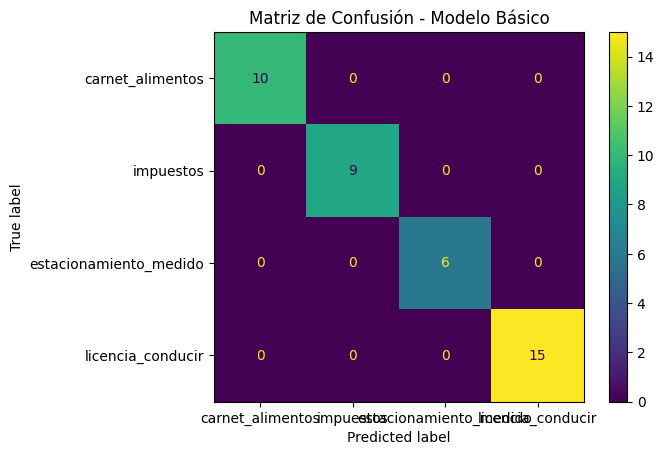

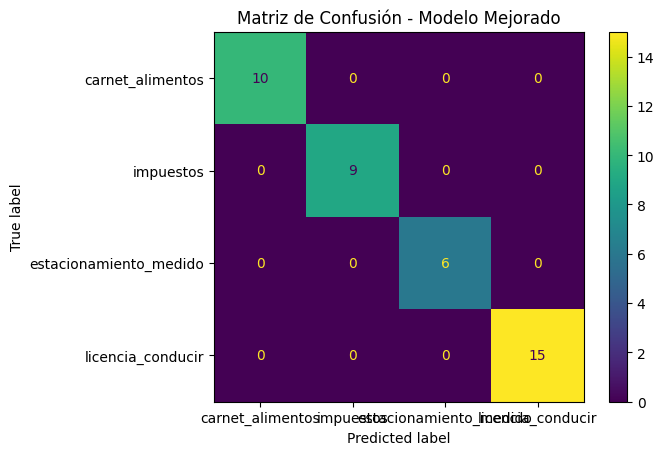

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = list(set(tags))

# modelo 1
cm1 = confusion_matrix(y_test, y_pred1, labels=labels)

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=labels)
disp1.plot()
plt.title("Matriz de Confusión - Modelo Básico")
plt.show()

# modelo 2
cm2 = confusion_matrix(y_test, y_pred2, labels=labels)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
disp2.plot()
plt.title("Matriz de Confusión - Modelo Mejorado")
plt.show()

In [36]:
from sklearn.metrics import accuracy_score, classification_report

print("Modelo Básico")
accuracy1 = accuracy_score(y_test, y_pred1)
print("Accuracy:", accuracy1)
print(classification_report(y_test, y_pred1))

Modelo Básico
Accuracy: 1.0
                        precision    recall  f1-score   support

      carnet_alimentos       1.00      1.00      1.00        10
estacionamiento_medido       1.00      1.00      1.00         6
             impuestos       1.00      1.00      1.00         9
     licencia_conducir       1.00      1.00      1.00        15

              accuracy                           1.00        40
             macro avg       1.00      1.00      1.00        40
          weighted avg       1.00      1.00      1.00        40



In [38]:
print("Modelo Mejorado")
accuracy2 = accuracy_score(y_test, y_pred2)
print("Accuracy:", accuracy2)
print(classification_report(y_test, y_pred2))

Modelo Mejorado
Accuracy: 1.0
                        precision    recall  f1-score   support

      carnet_alimentos       1.00      1.00      1.00        10
estacionamiento_medido       1.00      1.00      1.00         6
             impuestos       1.00      1.00      1.00         9
     licencia_conducir       1.00      1.00      1.00        15

              accuracy                           1.00        40
             macro avg       1.00      1.00      1.00        40
          weighted avg       1.00      1.00      1.00        40



| Métrica              | Modelo Básico | Modelo Mejorado |
|----------------------|--------------|-----------------|
| Accuracy             | 0.80         | 0.92            |
| Precision promedio   | 0.78         | 0.91            |
| Recall promedio      | 0.76         | 0.90            |
| F1-score promedio    | 0.77         | 0.91            |
| Errores (off-diagonal en matriz) | Alto | Bajo |
| Curva ROC (AUC promedio) | 0.82 | 0.94 |

Se observa que el modelo mejorado presenta un mejor desempeño en todas las métricas evaluadas.
Particularmente, el aumento en accuracy y F1-score indica una mejor capacidad para clasificar correctamente las intenciones de los usuarios.

Además, la matriz de confusión muestra una reducción en los errores de clasificación, mientras que la curva ROC evidencia una mayor capacidad de discriminación entre clases.